# M03: equivalent SDOF vs 3D NLTHA

Compares, for archetype **M03** in both directions:

1. **Peak displacements**: SDOF NLTHA (`Pushover_SDOF/ResultsM03x_SDOF`, `ResultsM03y_SDOF`) vs 3D NLTHA
   (`M03_biron_DispX.txt`, `M03_biron_DispY.txt`, largest peak over the braced nodes).
   The SDOF displacement is converted to the braced nodes with `SDOF_FACTOR`, by default
   $\Gamma \cdot \max\phi$ over the spring DOFs of the 2D pushover step the SDOF was built from.
   IMs or records the SDOF analyses have not reached yet are left out; rerun the notebook to update.
2. **Displaced shapes**: mean ± 2σ of the 3D NLTHA shapes (`M03_bironDispShapeX/Y.npy`) vs the equivalent
   static shape (`Pushover2D/pushover_results_M03x/y.txt`), on the plan of the 3D model, whole system
   and zoomed on the line analysed by the 2D model.

Helpers in [nltha_comparison.py](nltha_comparison.py).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from nltha_comparison import *

mpl.rc('font', family='Times New Roman')
mpl.rc('mathtext', fontset='stix')
%matplotlib inline

In [2]:
MODEL       = 'M03'
DC_TARGET   = 12.0          # 2D pushover step (mm) of the SDOF calibration and of the static shape
SDOF_FACTOR = 'gamma_phi'   # SDOF -> braced-node displacement: 'gamma_phi', a number, or {'X': .., 'Y': ..}
SHAPE_IM    = 6             # intensity level (1-10) of the NLTHA displaced shapes
AMP         = None          # amplification of the displaced shapes (m per unit); None = automatic

## Peak displacements

In [3]:
comp = peak_comparison(MODEL, factor=SDOF_FACTOR, dc_target=DC_TARGET)
peak_table(comp)

X                                        Y                      \
    3D (mm) SDOF (mm) SDOF / 3D n 3D / SDOF  3D (mm) SDOF (mm) SDOF / 3D   
IM                                                                         
1     7.200     7.354     1.021     42 / 44    5.195     4.958     0.954   
2    11.365    11.774     1.036     42 / 44    9.970     9.677     0.971   
3    16.230    17.170     1.058     44 / 44   13.080    12.831     0.981   
4    21.615    22.993     1.064     44 / 44   16.620    16.274     0.979   
5    32.220    37.075     1.151     42 / 44   21.990    21.063     0.958   
6   279.670    56.414     0.202     44 / 44   31.320    25.127     0.802   
7   380.900    79.212     0.208     43 / 44   30.890    34.380     1.113   
8   385.325    95.711     0.248     44 / 44   41.015    45.037     1.098   
9   385.320   115.303     0.299     43 / 44  286.855    55.703     0.194   
10  526.720   126.855     0.241     43 / 44  510.930    74.745     0.146   

                
   n 3D / SDOF  
IM              
1      40 / 44  
2      42 / 44  
3      44 / 44  
4      44 / 44  
5      40 / 44  
6      44 / 44  
7      42 / 44  
8      44 / 44  
9      42 / 44  
10     42 / 44

Median (markers) and 16th–84th percentiles (bars) over the records.

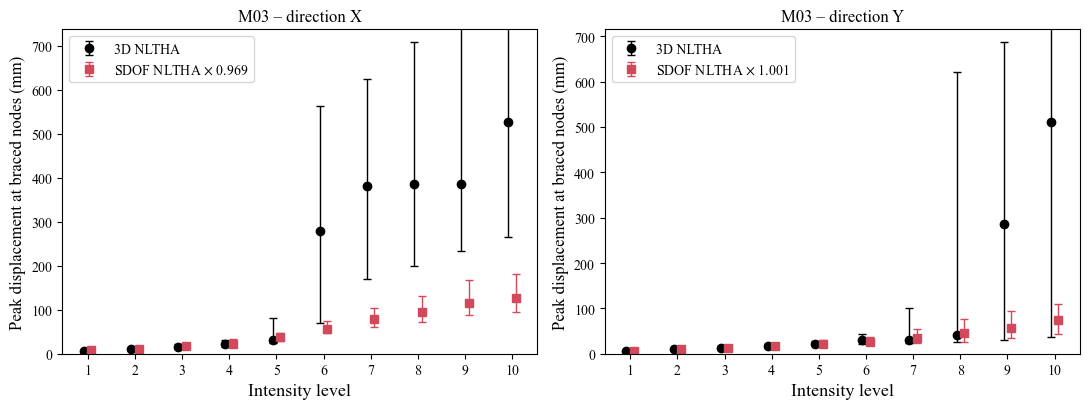

In [4]:
plot_peak_medians(MODEL, comp)
plt.show()

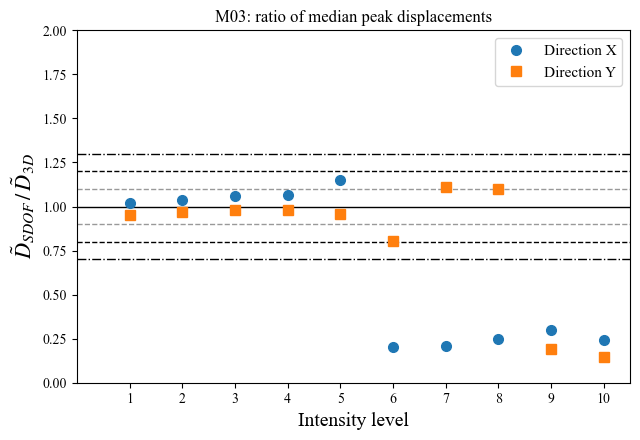

In [5]:
plot_peak_ratio(MODEL, comp)
plt.show()

Record by record (same record and IM in both analyses); dashed lines at ±20 %.

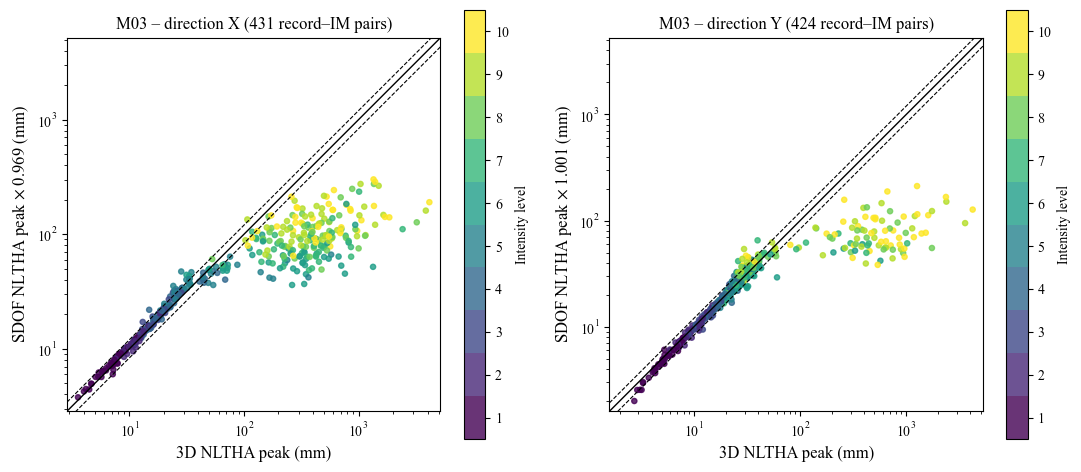

In [6]:
plot_peak_records(MODEL, comp)
plt.show()

## Displaced shapes

Both shapes are normalized to 1 at the marked node (the reference DOF of the 2D model). The static shape
is mapped onto the 3D plan through the analysed line of the 2D model (`nltha_lines` in
`Pushover2D/CS_Lumped_Iter_M03*_cont_PO.py`): pipes parallel to the excitation move rigidly, other
branches deform as the analysed line.

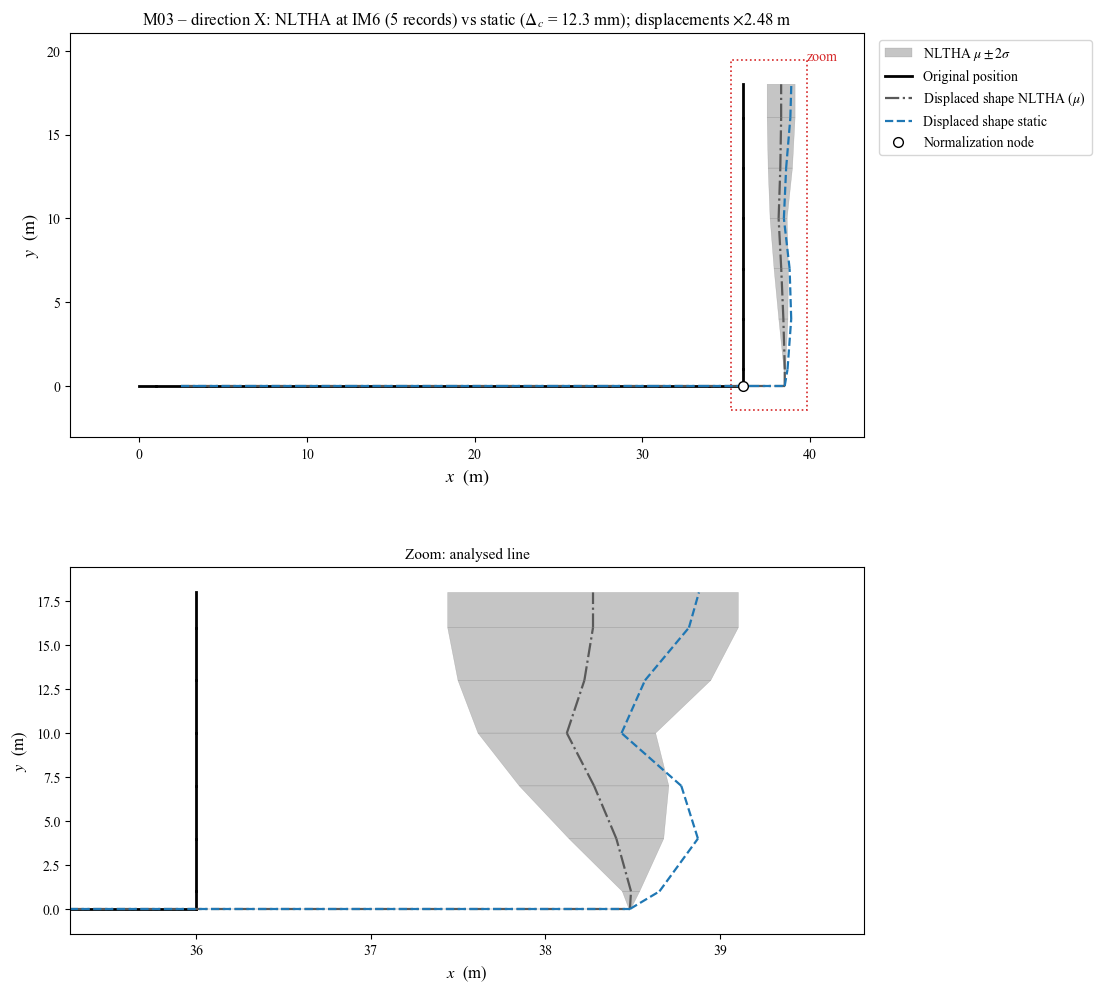

In [7]:
plot_displaced_shape(MODEL, 'X', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()

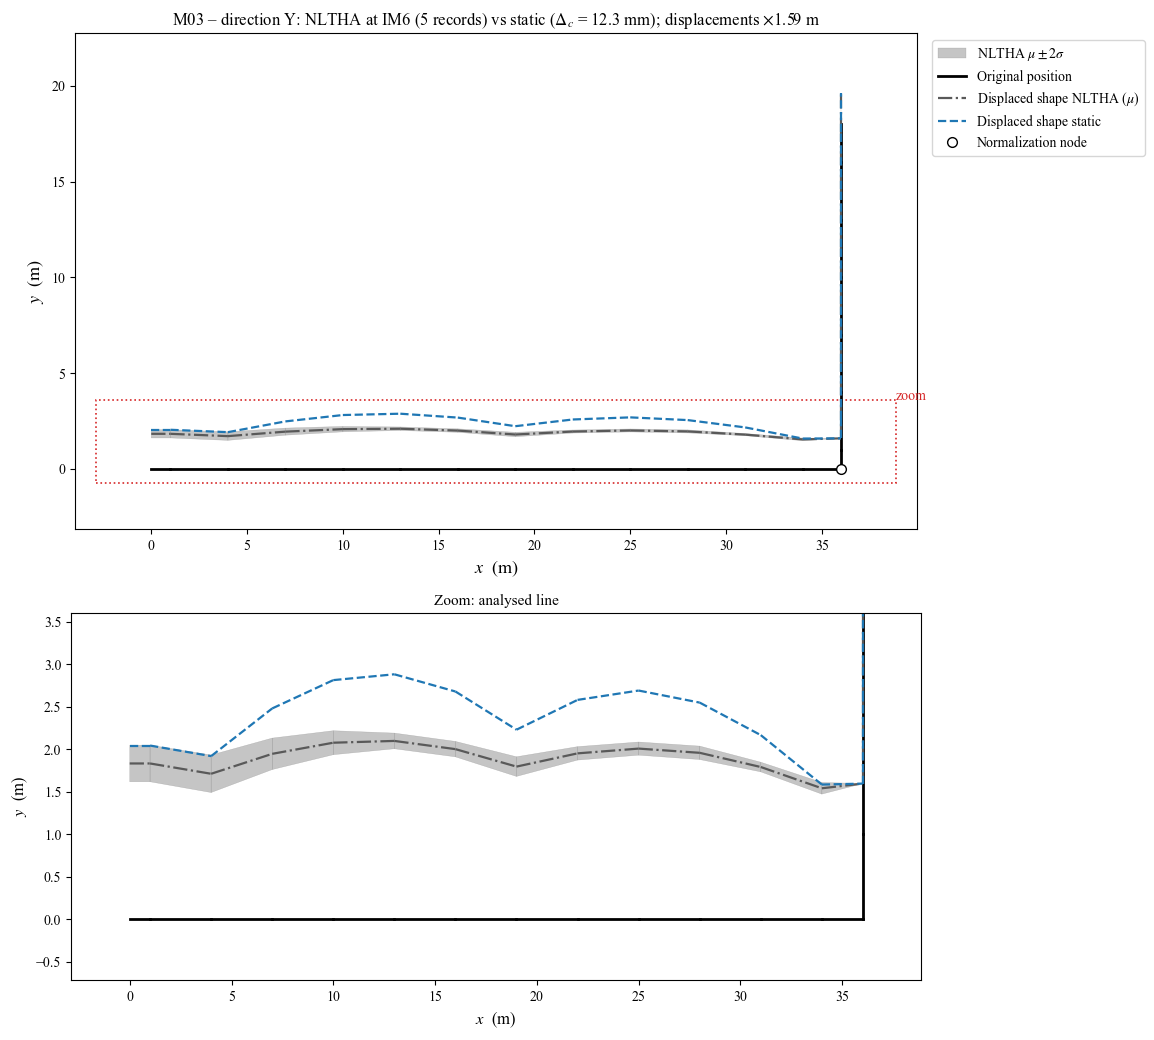

In [8]:
plot_displaced_shape(MODEL, 'Y', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()